In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import superstats as sup
import pandas as pd
import numpy as np

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/lschumacher/.local/share/uv/python/cpython-3.13.14-macos-aarch64-none/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
INFO:bayesflow:Using backend 'jax'


In [3]:
NUM_STEPS = 216

In [6]:
prior = sup.JointPrior(
    lamda = 1.0,
    # Raw 0--99 outcomes: use a low-curvature, slowly changing value function.
    alpha = sup.transition.RandomWalk(
        bounds=(0.2, 0.7),
        sigma=sup.Prior("halfnormal", scale=0.005),
        initial_prior=sup.Prior("normal", loc=-0.4, scale=0.25)
    ),
    # Center Prelec weighting on linear probability weighting.
    gamma = sup.transition.RandomWalk(
        bounds=(0.5, 1.5),
        sigma=sup.Prior("halfnormal", scale=0.005),
        initial_prior=sup.Prior("normal", loc=0.0, scale=0.25)
    ),
    # Raw outcomes require a much smaller tau than the scaled-outcome baseline.
    tau = sup.transition.RandomWalk(
        bounds=(1.0, 12.0),
        sigma=sup.Prior("halfnormal", scale=0.005),
        initial_prior=sup.Prior("normal", loc=0.0, scale=0.25)
    )
)
# prior = sup.JointPrior(
#     lamda = 1.0,
#     alpha = 0.4,
#     gamma = 1.0,
#     tau = 6.4
# )

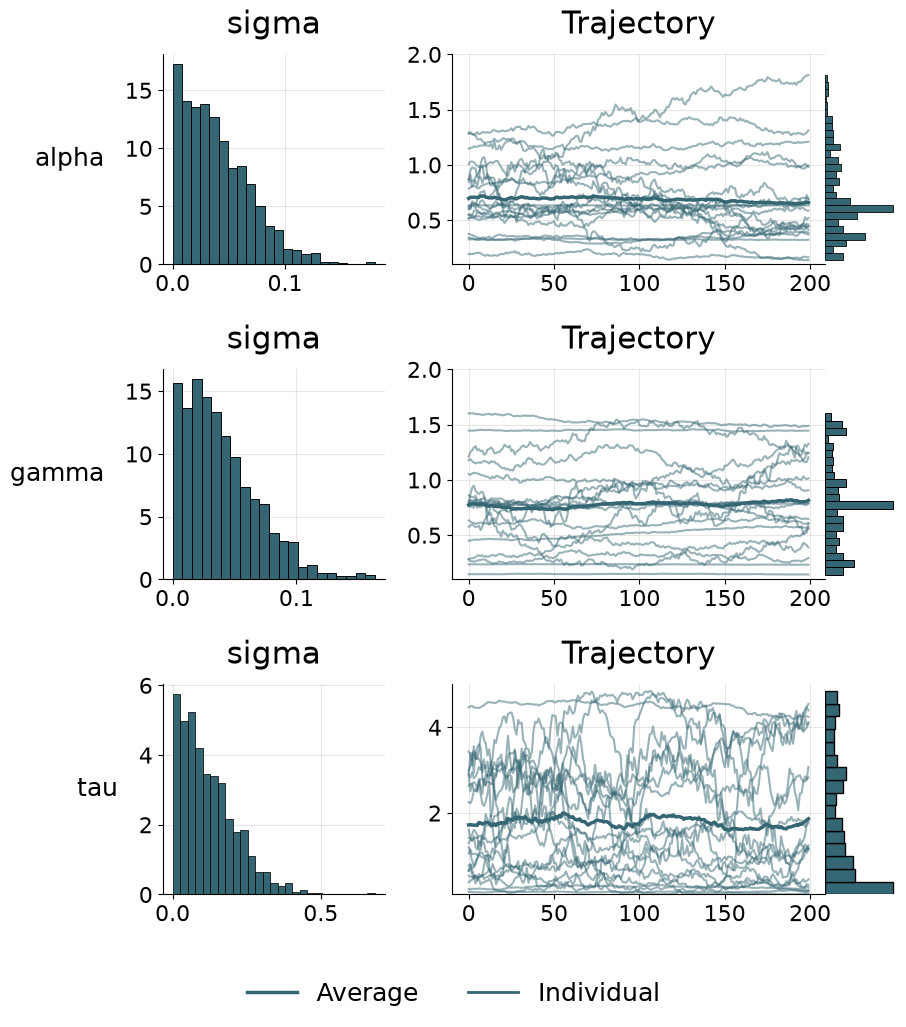

In [7]:
fig = prior.plot_joint_prior()

In [8]:
gamble_set = pd.read_csv("../data/representative_set.csv")
gamble_set = gamble_set[gamble_set["dominated_lottery"] == 0].reset_index(drop=True)

outcome_a = gamble_set[["outcome_a1", "outcome_a2"]].to_numpy(dtype=np.float32)
outcome_b = gamble_set[["outcome_b1", "outcome_b2"]].to_numpy(dtype=np.float32)
probability_a = gamble_set[["prob_a1", "prob_a2"]].to_numpy(dtype=np.float32)
probability_b = gamble_set[["prob_b1", "prob_b2"]].to_numpy(dtype=np.float32)

outcome_a = np.concatenate([outcome_a] * 4, axis=0)
outcome_b = np.concatenate([outcome_b] * 4, axis=0)
probability_a = np.concatenate([probability_a] * 4, axis=0)
probability_b = np.concatenate([probability_b] * 4, axis=0)

outcome_a.shape


(216, 2)

In [9]:
def generate_context(batch_size, num_steps, rng=None):
    """Generate independently shuffled contexts for each batch element."""

    if rng is None:
        rng = np.random.default_rng()

    variables = {
        "outcomes_a": outcome_a,
        "outcomes_b": outcome_b,
        "probabilities_a": probability_a,
        "probabilities_b": probability_b,
    }

    num_available = outcome_a.shape[0]

    if num_available != 216:
        raise ValueError(
            f"Expected 216 available context rows, got {num_available}."
        )

    contexts = {
        name: np.empty((batch_size, num_steps, values.shape[1]), dtype=values.dtype)
        for name, values in variables.items()
    }

    for batch_idx in range(batch_size):
        if num_steps < 216:
            # Select existing rows without replacement.
            indices = rng.choice(216, size=num_steps, replace=False)

        elif num_steps == 216:
            # Use every row exactly once.
            indices = np.arange(216)

        else:
            # Use every row, then sample additional rows with replacement.
            extra_indices = rng.choice(
                216,
                size=num_steps - 216,
                replace=True,
            )
            indices = np.concatenate([np.arange(216), extra_indices])

        # Shuffle the complete sequence for this batch element.
        indices = rng.permutation(indices)

        for name, values in variables.items():
            contexts[name][batch_idx] = values[indices]

    return contexts

In [10]:
context_simulator = sup.ContextSimulator(
    simulator=generate_context
)

context_mapping = sup.ContextMapping(
    simulator_context=(
        "outcomes_a", "outcomes_b",
        "probabilities_a", "probabilities_b"
    )
)

In [11]:
model = sup.Model(
    prior=prior,
    simulator=sup.simulation.cognitive.sample_cpt,
    context=context_simulator,
    context_mapping=context_mapping,
    missing=None,
    contamination=None
)

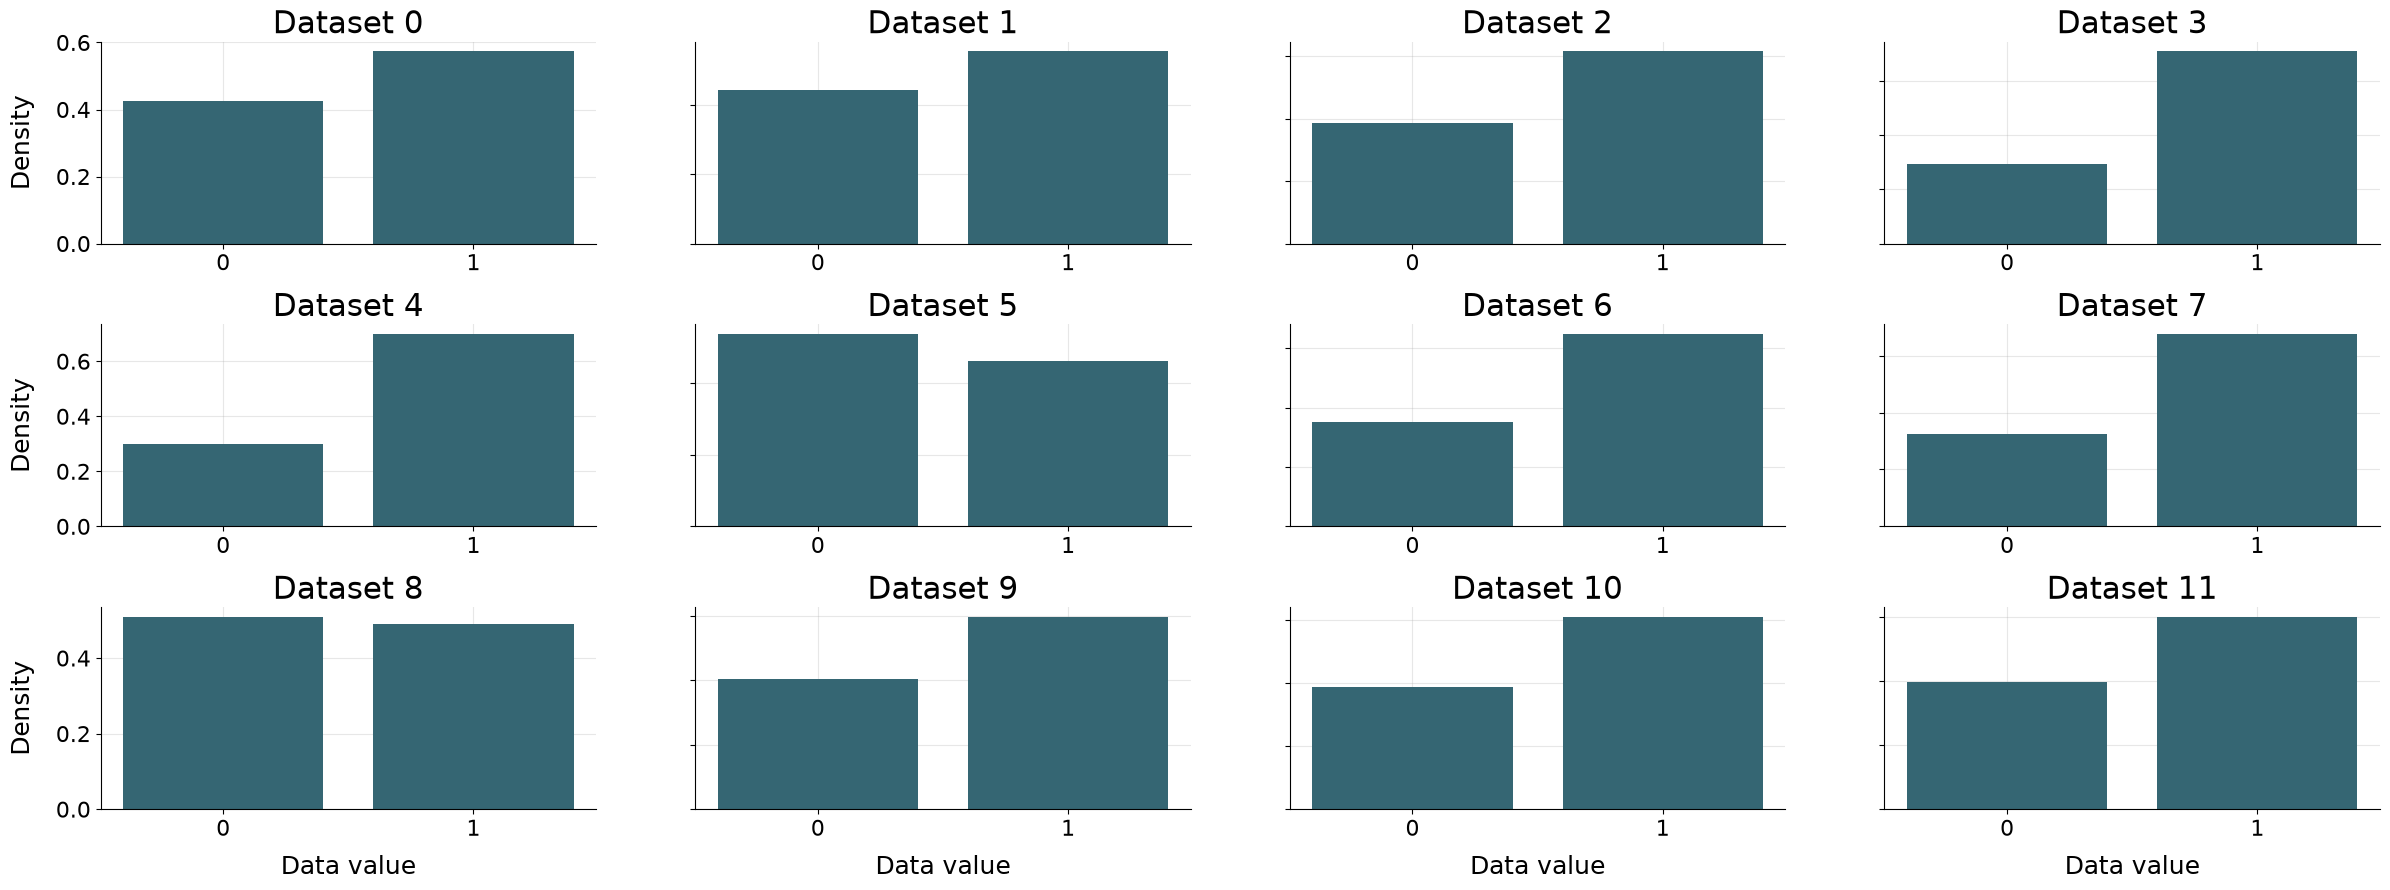

In [12]:
fig = model.plot_push_forward(
    batch_size=12,
    num_steps=NUM_STEPS,
    data_dim=0,
    kind="dist",
    aggregation=None
)

In [13]:
workflow = sup.Workflow(
    model=model,
    # checkpoint_filepath="checkpoints/dynamic_cpt"
)

In [ ]:
train_data = model.sample(
    batch_size=10_000,
    num_steps=NUM_STEPS,
    tile_to_steps=True
)

val_data = model.sample(
    batch_size=100,
    num_steps=NUM_STEPS,
    tile_to_steps=True
)

In [ ]:
history = workflow.fit_offline(
    data=train_data,
    validation_data=val_data,
    epochs=20,
    batch_size=32
)

In [ ]:
fig = workflow.plot_history(workflow.history)

In [ ]:
targets = model.sample(batch_size=250, num_steps=NUM_STEPS)

In [ ]:
samples = workflow.sample(data=targets, num_samples=500, batch_size=4)

In [ ]:
fig = workflow.verify_time_varying(targets=targets, estimates=samples)

In [ ]:
fig = workflow.verify_time_invariant(targets=targets, estimates=samples)